# Internações que a atenção primária poderia ter evitado

**A pergunta:** parte das internações do SUS não deveria ter acontecido. Não
por erro do hospital — por falha lá atrás, na unidade básica que não controlou
a pressão, não ajustou a insulina, não tratou a pneumonia a tempo. O Ministério
da Saúde publicou uma lista oficial dessas causas, e a proporção delas é hoje
o principal indicador de desempenho da atenção primária brasileira.

Este notebook calcula esse indicador — as **ICSAP**, Internações por Condições
Sensíveis à Atenção Primária, da Portaria SAS/MS nº 221/2008 — e mostra quanto
elas custam.

**Fonte:** Sistema de Informações Hospitalares (SIH/SUS), grupo RD (AIH
reduzida), com denominadores do IBGE.

**Tempo estimado:** 4 a 8 minutos.

**O que você leva daqui:** a lista das 19 condições implementada em código
auditável, a proporção de ICSAP do seu estado, o custo dessas internações e o
mapa dos municípios onde elas mais pesam.

In [2]:
%pip install pysus==2.10.6 nest_asyncio duckdb -q

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nest_asyncio
nest_asyncio.apply()

import os
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
con = duckdb.connect()

def mil(numero):
    "Número no padrão brasileiro: 1234567 vira 1.234.567."
    return f"{numero:,.0f}".replace(",", ".")

def reais(valor):
    "Valor em reais, com separador de milhar."
    return "R$ " + f"{valor:,.2f}".replace(",", "@").replace(".", ",").replace("@", ".")

print("Ambiente pronto.")

Ambiente pronto.


## 1. O que você pode trocar

In [4]:
UF = "PR"       # estado analisado

UFS = {
    11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA", 16: "AP", 17: "TO",
    21: "MA", 22: "PI", 23: "CE", 24: "RN", 25: "PB", 26: "PE", 27: "AL",
    28: "SE", 29: "BA", 31: "MG", 32: "ES", 33: "RJ", 35: "SP",
    41: "PR", 42: "SC", 43: "RS", 50: "MS", 51: "MT", 52: "GO", 53: "DF",
}
CODIGO_UF = {sigla: codigo for codigo, sigla in UFS.items()}
print(f"Estado analisado: {UF}")

Estado analisado: PR


## 2. A armadilha do SIH: existem dois arquivos, e o errado é o primeiro

Esta é a pegadinha que mais custa tempo a quem começa. Ao pedir um mês do SIH,
a biblioteca devolve **uma lista de arquivos**, não um só. E o primeiro da
lista costuma ser o **SP — Serviços Profissionais**, que tem uma linha para
cada procedimento cobrado por cada profissional. Quem pega `[0]` acha que tem
um milhão de internações quando tem um milhão de *atos médicos*.

O arquivo das internações é o **RD**, a AIH reduzida: uma linha por internação,
com diagnóstico, tempo de permanência, valor pago e desfecho.

A diferença de tamanho entre os dois já denuncia a confusão.

In [5]:
from pysus import list_files

catalogo = list_files(dataset="sih", state=UF)
catalogo["arquivo"] = [os.path.basename(str(n).replace("\\", "/"))
                       for n in catalogo["name"]]
catalogo["grupo"] = catalogo["arquivo"].str[:2].str.upper()

resumo = catalogo.groupby("grupo").agg(
    arquivos=("arquivo", "size"), de=("year", "min"), ate=("year", "max"))
resumo["o que é"] = resumo.index.map({
    "RD": "AIH reduzida — UMA LINHA POR INTERNAÇÃO (é este que queremos)",
    "SP": "Serviços profissionais — uma linha por ato de cada profissional",
    "RJ": "AIH rejeitada",
    "ER": "AIH rejeitada com erro",
})
resumo

,arquivos,de,ate,o que é
grupo,,,,
ER,186,2011.0,2026.0,AIH rejeitada com erro
RD,415,1992.0,2026.0,AIH reduzida — UMA LINHA POR INTERNAÇÃO (é est...
RJ,240,2006.0,2026.0,AIH rejeitada
SP,349,1997.0,2026.0,Serviços profissionais — uma linha por ato de ...


In [6]:
# Meses com o grupo RD publicado, do mais recente para o mais antigo.
rd = catalogo[catalogo["grupo"] == "RD"].copy()
rd["mes"] = pd.to_numeric(rd["arquivo"].str[6:8], errors="coerce")
rd = rd.dropna(subset=["mes", "year"]).sort_values(["year", "mes"])

recentes = rd[rd["year"] >= rd["year"].max() - 3]
print(f"Meses com internações (grupo RD) publicados para {UF}:\n")
for ano, grupo in recentes.groupby("year"):
    meses = sorted(int(m) for m in grupo["mes"])
    marca = "" if len(meses) == 12 else f"  <- só {len(meses)} meses"
    print(f"  {int(ano)}: {meses}{marca}")

# O ano mais recente costuma estar EM ANDAMENTO, e meio ano nao se compara com
# referencia anual: internacao respiratoria tem estacao. Pegamos o ultimo ano
# COMPLETO, que e o que permite comparar com o Brasil.
por_ano = rd.groupby(rd["year"].astype(int))["mes"].nunique()
completos = sorted(por_ano[por_ano == 12].index)
if not completos:
    raise ValueError("Nenhum ano tem os doze meses do grupo RD no catálogo.")
ANO = int(completos[-1])
MESES = sorted(int(m) for m in rd[rd["year"] == ANO]["mes"])
print(f"\nVamos usar {UF}, {ANO}, os {len(MESES)} meses do ano.")
descartados = sorted(set(int(a) for a in rd["year"]) - set(completos))
if descartados:
    print(f"Anos descartados por estarem incompletos: {descartados[-3:]}")
print()
print("Por que o ano inteiro, e não o mês mais recente: internação evitável tem")
print("estação — bronquite e pneumonia enchem o inverno. Um mês solto comparado")
print("com uma referência anual mede o calendário, não a atenção primária.")

Meses com internações (grupo RD) publicados para PR:
  2023: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  2024: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  2025: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  2026: [1, 2, 3, 4, 5, 6]  <- só 6 meses
Vamos usar PR, 2025, os 12 meses do ano.
Anos descartados por estarem incompletos: [2026]
Por que o ano inteiro, e não o mês mais recente: internação evitável tem
estação — bronquite e pneumonia enchem o inverno. Um mês solto comparado
com uma referência anual mede o calendário, não a atenção primária.


In [7]:
from pysus import sih

def arquivos_rd(uf, ano, meses):
    """Baixa o mês pedido e devolve SÓ os arquivos do grupo RD.

    Nunca use caminhos[0]: o primeiro da lista costuma ser o SP.
    """
    escolhidos = []
    for mes in meses:
        for caminho in sih(uf, ano, mes):
            if os.path.basename(caminho).upper().startswith("RD"):
                escolhidos.append(caminho.replace("\\", "/"))
    return escolhidos

caminhos = arquivos_rd(UF, ANO, MESES)
lista = ", ".join(f"'{c}'" for c in caminhos)

for caminho in caminhos:
    n = con.execute(f"SELECT count(*) FROM read_parquet('{caminho}')").fetchone()[0]
    print(f"  {os.path.basename(caminho):<18} {mil(n):>10} internações")

colunas = con.execute(f"DESCRIBE SELECT * FROM read_parquet([{lista}])").df()
print(f"\nA AIH reduzida tem {len(colunas)} campos.")

RDPR2501.parquet       87.482 internações
  RDPR2502.parquet       85.810 internações
  RDPR2503.parquet       88.023 internações
  RDPR2504.parquet       91.035 internações
  RDPR2505.parquet       93.300 internações
  RDPR2506.parquet       94.036 internações
  RDPR2507.parquet       95.792 internações
  RDPR2508.parquet       93.912 internações
  RDPR2509.parquet       94.437 internações
  RDPR2510.parquet       96.026 internações
  RDPR2511.parquet       91.835 internações
  RDPR2512.parquet       89.610 internações
A AIH reduzida tem 113 campos.


In [8]:
internacoes = con.execute(f"""
    SELECT DIAG_PRINC, PROC_REA, IDADE, COD_IDADE, SEXO, MUNIC_RES, MUNIC_MOV,
           DIAS_PERM, MORTE, VAL_TOT, CAR_INT, ESPEC, UTI_MES_TO, CNES
    FROM read_parquet([{lista}])
""").df()

for coluna in ["IDADE", "DIAS_PERM", "VAL_TOT", "UTI_MES_TO"]:
    internacoes[coluna] = pd.to_numeric(internacoes[coluna], errors="coerce")

print(f"{mil(len(internacoes))} internações carregadas")
print(f"Valor total pago: {reais(internacoes['VAL_TOT'].sum())}")
print(f"Permanência média: {internacoes['DIAS_PERM'].mean():.1f} dias")
print(f"Óbitos hospitalares: {mil((internacoes['MORTE'].astype(str) == '1').sum())}")
internacoes.head(3)

1.101.298 internações carregadas
Valor total pago: R$ 2.222.028.008,99
Permanência média: 4.0 dias
Óbitos hospitalares: 42.018


,DIAG_PRINC,PROC_REA,IDADE,COD_IDADE,SEXO,MUNIC_RES,MUNIC_MOV,DIAS_PERM,MORTE,VAL_TOT,CAR_INT,ESPEC,UTI_MES_TO,CNES
0,F29,0303170190,23,4,1,410200,411950,7,0,366.03,01,05,0,0018384
1,F192,0303170190,26,4,1,410180,411950,22,0,1281.12,01,05,0,0018384
2,F192,0303170190,22,4,1,411990,411950,23,0,1342.12,01,05,0,0018384


### Idade no SIH: mais um código que engana

A idade vem em dois campos: `IDADE` é o número, e `COD_IDADE` diz a unidade —
anos, meses, dias ou horas. Um bebê de três dias aparece como idade 3. Sem
juntar os dois, a média de idade do hospital despenca sem motivo.

In [9]:
def idade_em_anos(idade, unidade):
    """Idade em anos completos, combinando IDADE e COD_IDADE.

    COD_IDADE: 2 dias, 3 meses, 4 anos, 5 anos acima de cem.
    """
    codigo = str(unidade).strip()
    if pd.isna(idade):
        return None
    if codigo == "5":
        return 100 + idade
    if codigo == "4":
        return idade
    return 0        # horas, dias ou meses: menos de um ano

internacoes["idade_anos"] = [
    idade_em_anos(i, u) for i, u in zip(internacoes["IDADE"], internacoes["COD_IDADE"])
]

print("Distribuição do campo COD_IDADE:")
print(internacoes["COD_IDADE"].value_counts().head())
print()
print(f"Idade média ignorando a unidade: {internacoes['IDADE'].mean():.1f}")
print(f"Idade média corrigida:           {internacoes['idade_anos'].mean():.1f} anos")

Distribuição do campo COD_IDADE:
COD_IDADE
4    1058218
2      25198
3      17361
5        521
Name: count, dtype: int64
Idade média ignorando a unidade: 45.7
Idade média corrigida:           45.5 anos


## 3. A lista oficial das condições sensíveis

São 19 grupos de causas, definidos pela Portaria SAS/MS nº 221 de 2008. A
lógica é simples: são doenças em que uma atenção primária funcionando bem
evita a internação — ou porque previne (vacina), ou porque controla
(hipertensão, diabetes), ou porque trata cedo (pneumonia, infecção urinária).

A lista está escrita abaixo em código, para que você possa auditar cada linha.

In [10]:
ICSAP = {
    "1. Preveníveis por imunização": [
        "A33", "A34", "A35", "A36", "A37", "A95", "B05", "B06", "B16", "B26",
        "B77", "G000", "A170", "A19"],
    "2. Gastroenterites e desidratação": ["E86"] + [f"A0{i}" for i in range(10)],
    "3. Anemia": ["D50"],
    "4. Deficiências nutricionais": [f"E4{i}" for i in range(0, 7)]
                                    + [f"E{i}" for i in range(50, 65)],
    "5. Infecções de ouvido, nariz e garganta": [
        "H66", "J00", "J01", "J02", "J03", "J06", "J31"],
    "6. Pneumonias bacterianas": ["J13", "J14", "J153", "J154", "J158", "J159", "J181"],
    "7. Asma": ["J45", "J46"],
    "8. Doenças pulmonares crônicas": [
        "J20", "J21", "J40", "J41", "J42", "J43", "J44", "J47"],
    "9. Hipertensão": ["I10", "I11"],
    "10. Angina": ["I20"],
    "11. Insuficiência cardíaca": ["I50", "J81"],
    "12. Doenças cerebrovasculares": [
        "I63", "I64", "I65", "I66", "I67", "I69", "G45", "G46"],
    "13. Diabetes": ["E10", "E11", "E12", "E13", "E14"],
    "14. Epilepsias": ["G40", "G41"],
    "15. Infecção urinária": ["N10", "N11", "N12", "N30", "N34", "N390"],
    "16. Infecção da pele e tecido subcutâneo": [
        "A46", "L01", "L02", "L03", "L04", "L08"],
    "17. Doença inflamatória pélvica feminina": [
        "N70", "N71", "N72", "N73", "N75", "N76"],
    "18. Úlcera gastrointestinal": [
        "K25", "K26", "K27", "K28", "K920", "K921", "K922"],
    "19. Relacionadas ao pré-natal e parto": ["O23", "A50", "P350"],
}

# Índice para busca rápida: do código mais específico para o mais geral.
CODIGOS_ICSAP = {}
for grupo, codigos in ICSAP.items():
    for codigo in codigos:
        CODIGOS_ICSAP[codigo] = grupo

def grupo_icsap(diagnostico):
    """Devolve o grupo da lista de condições sensíveis, ou None.

    Testa primeiro o código de 4 caracteres (mais específico) e depois o de 3,
    porque a lista mistura os dois níveis — J15.3 entra, J15.0 não.
    """
    codigo = str(diagnostico).strip().upper()
    if len(codigo) < 3:
        return None
    return CODIGOS_ICSAP.get(codigo[:4]) or CODIGOS_ICSAP.get(codigo[:3])

total_codigos = sum(len(c) for c in ICSAP.values())
print(f"{len(ICSAP)} grupos, {total_codigos} códigos da CID-10.")
for exemplo in ["I10", "E119", "J449", "J150", "J153", "S720", "O800"]:
    print(f"  {exemplo:<5} -> {grupo_icsap(exemplo) or 'não é condição sensível'}")

19 grupos, 120 códigos da CID-10.
  I10   -> 9. Hipertensão
  E119  -> 13. Diabetes
  J449  -> 8. Doenças pulmonares crônicas
  J150  -> não é condição sensível
  J153  -> 6. Pneumonias bacterianas
  S720  -> não é condição sensível
  O800  -> não é condição sensível


Repare no par `J150` e `J153`: os dois são pneumonia, mas só o segundo está na
lista. É por isso que a função testa o código de quatro caracteres antes do de
três — trocar essa ordem inflaria o indicador.

## 4. O indicador

Uma convenção importante: **os partos ficam de fora do denominador.** Internar
para dar à luz não é falha de atenção primária, e incluir os partos diluiria o
indicador em estados com mais nascimentos. A definição oficial exclui o
capítulo XV da CID-10 (gravidez, parto e puerpério) do total, mantendo apenas
o grupo 19, que trata de complicações evitáveis do pré-natal.

In [11]:
internacoes["icsap"] = internacoes["DIAG_PRINC"].map(grupo_icsap)
internacoes["obstetrico"] = internacoes["DIAG_PRINC"].astype(str).str.upper().str.startswith("O")

elegiveis = internacoes[~internacoes["obstetrico"] | internacoes["icsap"].notna()]
sensiveis = elegiveis[elegiveis["icsap"].notna()]

proporcao = len(sensiveis) / len(elegiveis) * 100

print(f"Internações no período:            {mil(len(internacoes))}")
print(f"Partos e causas obstétricas:       {mil(internacoes['obstetrico'].sum())}")
print(f"Denominador (sem partos):          {mil(len(elegiveis))}")
print(f"Sensíveis à atenção primária:      {mil(len(sensiveis))}")
print()
print(f"PROPORÇÃO DE ICSAP — {UF}, {ANO}:  {proporcao:.1f}%")
print()
print("Referência: o Brasil vinha de cerca de 28% em 2010 para algo entre 18%")
print("e 22% nos últimos anos. Estados com atenção primária mais consolidada")
print("ficam abaixo de 15%.")

Internações no período:            1.101.298
Partos e causas obstétricas:       116.108
Denominador (sem partos):          986.325
Sensíveis à atenção primária:      157.794
PROPORÇÃO DE ICSAP — PR, 2025:  16.0%
Referência: o Brasil vinha de cerca de 28% em 2010 para algo entre 18%
e 22% nos últimos anos. Estados com atenção primária mais consolidada
ficam abaixo de 15%.


In [12]:
por_grupo = (
    sensiveis.groupby("icsap")
    .agg(Internações=("VAL_TOT", "size"),
         **{"Custo total": ("VAL_TOT", "sum"),
            "Permanência média": ("DIAS_PERM", "mean"),
            "Óbitos": ("MORTE", lambda s: (s.astype(str) == "1").sum())})
)
por_grupo["% das ICSAP"] = (por_grupo["Internações"] / len(sensiveis) * 100).round(1)
por_grupo["Letalidade (%)"] = (por_grupo["Óbitos"] / por_grupo["Internações"] * 100).round(1)
por_grupo["Permanência média"] = por_grupo["Permanência média"].round(1)
por_grupo = por_grupo.sort_values("Internações", ascending=False)

por_grupo[["Internações", "% das ICSAP", "Permanência média",
           "Letalidade (%)", "Custo total"]].head(10)

,Internações,% das ICSAP,Permanência média,Letalidade (%),Custo total
icsap,,,,,
11. Insuficiência cardíaca,20855,13.2,5.8,9.2,5.405868e+07
12. Doenças cerebrovasculares,20807,13.2,6.1,9.3,5.207393e+07
15. Infecção urinária,19955,12.6,4.1,2.6,1.043211e+07
10. Angina,17754,11.3,4.6,2.5,1.396783e+08
8. Doenças pulmonares crônicas,16546,10.5,4.6,4.6,1.996598e+07
13. Diabetes,8222,5.2,4.5,2.4,1.013120e+07
2. Gastroenterites e desidratação,8042,5.1,3.1,1.4,4.016206e+06
16. Infecção da pele e tecido subcutâneo,8017,5.1,5.0,1.6,6.276149e+06
14. Epilepsias,7984,5.1,4.2,2.3,1.301886e+07


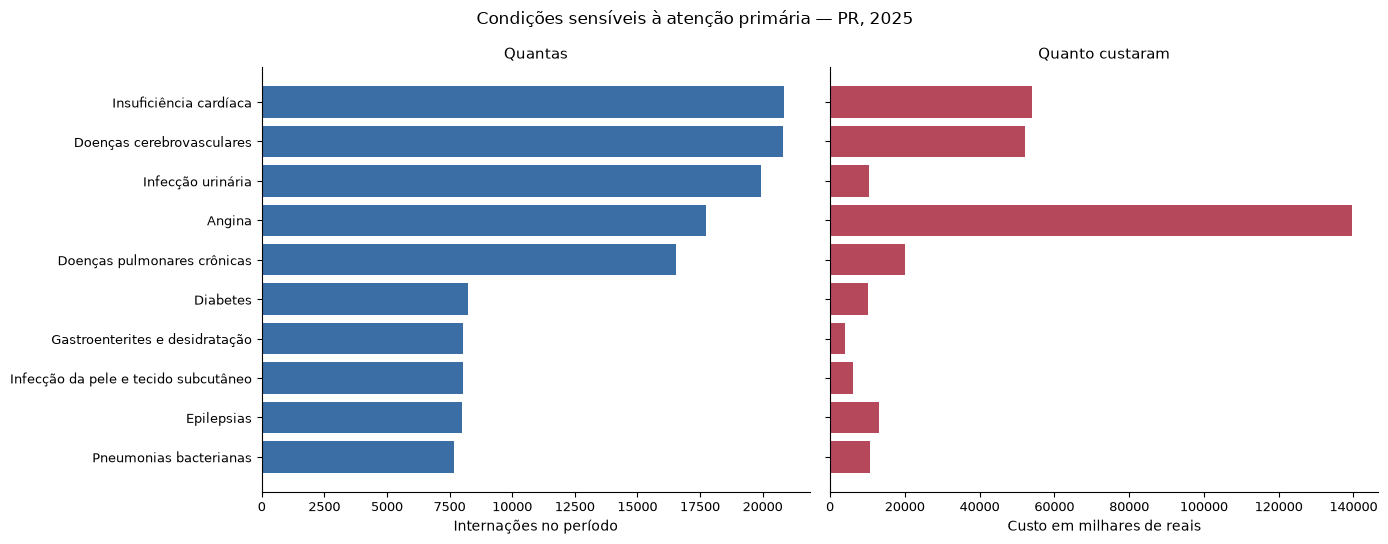

In [13]:
principais = por_grupo.head(10).iloc[::-1]
rotulos = [i.split(". ", 1)[1] for i in principais.index]

figura, (eixo1, eixo2) = plt.subplots(1, 2, figsize=(14, 5.5))

eixo1.barh(rotulos, principais["Internações"], color="#3b6ea5")
eixo1.set_xlabel("Internações no período")
eixo1.set_title("Quantas", fontsize=11)

eixo2.barh(rotulos, principais["Custo total"] / 1000, color="#b5495b")
eixo2.set_xlabel("Custo em milhares de reais")
eixo2.set_title("Quanto custaram", fontsize=11)
eixo2.set_yticklabels([])

for eixo in (eixo1, eixo2):
    eixo.spines[["top", "right"]].set_visible(False)
    eixo.tick_params(labelsize=9)

plt.suptitle(f"Condições sensíveis à atenção primária — {UF}, {ANO}", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Quem interna por causa evitável

A distribuição por idade é a parte mais reveladora: as ICSAP se concentram nas
duas pontas da vida, e por motivos diferentes. Nas crianças, são infecções e
gastroenterites; nos idosos, o descontrole das doenças crônicas.

In [14]:
FAIXAS = [(0, 0), (1, 4), (5, 14), (15, 29), (30, 44),
          (45, 59), (60, 74), (75, 199)]
ROTULOS = ["< 1 ano", "1-4", "5-14", "15-29", "30-44", "45-59", "60-74", "75+"]

def faixa_de(idade):
    if pd.isna(idade):
        return None
    for (minimo, maximo), rotulo in zip(FAIXAS, ROTULOS):
        if minimo <= idade <= maximo:
            return rotulo
    return None

elegiveis = elegiveis.assign(faixa=elegiveis["idade_anos"].map(faixa_de))
por_idade = (
    elegiveis.dropna(subset=["faixa"])
    .groupby("faixa")
    .agg(Internações=("icsap", "size"),
         ICSAP=("icsap", lambda s: s.notna().sum()))
    .reindex(ROTULOS)
)
por_idade["% sensíveis"] = (por_idade["ICSAP"] / por_idade["Internações"] * 100).round(1)
por_idade

,Internações,ICSAP,% sensíveis
faixa,,,
< 1 ano,42544,7790,18.3
1-4,34838,8358,24.0
5-14,58645,7350,12.5
15-29,108357,10930,10.1
30-44,159256,13070,8.2
45-59,207828,25989,12.5
60-74,235395,46323,19.7
75+,139462,37984,27.2


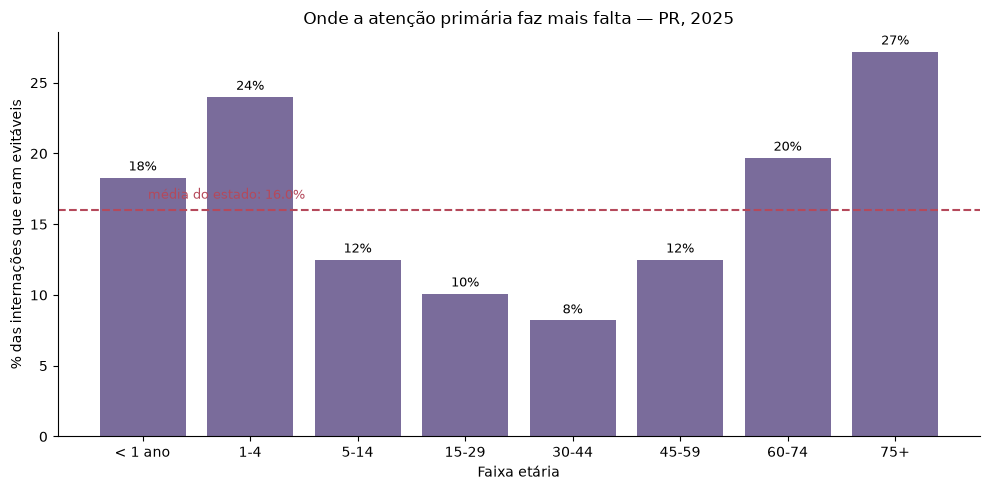

In [15]:
figura, eixo = plt.subplots(figsize=(10, 5))
eixo.bar(por_idade.index, por_idade["% sensíveis"], color="#7a6c9b")
eixo.axhline(proporcao, color="#b5495b", linestyle="--", linewidth=1.5)
eixo.text(0.05, proporcao + 0.8, f"média do estado: {proporcao:.1f}%",
          color="#b5495b", fontsize=9)

for indice, valor in enumerate(por_idade["% sensíveis"]):
    eixo.text(indice, valor + 0.5, f"{valor:.0f}%", ha="center", fontsize=9)

eixo.set_ylabel("% das internações que eram evitáveis")
eixo.set_xlabel("Faixa etária")
eixo.set_title(f"Onde a atenção primária faz mais falta — {UF}, {ANO}", fontsize=12)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. O que isso custa

O valor pago pelo SUS em cada AIH está no arquivo. Somado, ele dá a conta do
que se gastou tratando no hospital o que poderia ter sido resolvido antes.

In [16]:
custo_icsap = sensiveis["VAL_TOT"].sum()
custo_total = elegiveis["VAL_TOT"].sum()
dias_icsap = sensiveis["DIAS_PERM"].sum()

print(f"Período analisado: {len(MESES)} mês(es) de {ANO}\n")
print(f"Gasto com internações evitáveis:  {reais(custo_icsap)}")
print(f"Gasto total (sem partos):         {reais(custo_total)}")
print(f"Fatia do orçamento hospitalar:    {custo_icsap / custo_total * 100:.1f}%")
print()
print(f"Dias de internação evitáveis:     {mil(dias_icsap)}")
print(f"Equivalente a ocupar {dias_icsap / (30 * len(MESES)):.0f} leitos "
      f"todos os dias do período.")
print()
print(f"Custo médio de uma internação evitável: {reais(sensiveis['VAL_TOT'].mean())}")

Período analisado: 12 mês(es) de 2025
Gasto com internações evitáveis:  R$ 338.636.046,08
Gasto total (sem partos):         R$ 2.150.618.299,28
Fatia do orçamento hospitalar:    15.7%
Dias de internação evitáveis:     737.065
Equivalente a ocupar 2047 leitos todos os dias do período.
Custo médio de uma internação evitável: R$ 2.146,06


A última linha é a que costuma mudar uma conversa de gestão: essas internações
ocupam leitos de forma contínua. Não é dinheiro apenas — é fila de cirurgia
que não anda.

## 7. Onde, no mapa do estado

A proporção de ICSAP por município de residência mostra onde a rede básica
está mais frágil. Municípios pequenos aparecem com números instáveis, então
filtramos os que têm poucas internações no período.

In [17]:
minimo_internacoes = 100

por_municipio = (
    elegiveis.groupby("MUNIC_RES")
    .agg(Internações=("icsap", "size"),
         ICSAP=("icsap", lambda s: s.notna().sum()),
         **{"Custo": ("VAL_TOT", "sum")})
)
por_municipio = por_municipio[por_municipio["Internações"] >= minimo_internacoes]
por_municipio["% sensíveis"] = (
    por_municipio["ICSAP"] / por_municipio["Internações"] * 100).round(1)
por_municipio = por_municipio.sort_values("% sensíveis", ascending=False)

print(f"{len(por_municipio)} municípios com pelo menos "
      f"{minimo_internacoes} internações no período.")
print("(o código é o do IBGE com seis dígitos — 410690 é Curitiba)\n")
print("Os dez com maior proporção de internações evitáveis:")
display(por_municipio.head(10))
print("\nOs cinco com menor proporção:")
por_municipio.tail(5)

418 municípios com pelo menos 100 internações no período.
(o código é o do IBGE com seis dígitos — 410690 é Curitiba)
Os dez com maior proporção de internações evitáveis:


,Internações,ICSAP,Custo,% sensíveis
MUNIC_RES,,,,
410570,1920,972,2374507.45,50.6
411980,1780,749,2681638.33,42.1
412200,1501,525,2486043.77,35.0
411240,1098,361,1653456.51,32.9
412250,1519,498,2321561.68,32.8
411040,719,236,1015409.19,32.8
410750,1717,557,2191100.89,32.4
411250,1864,574,2551677.32,30.8
412260,1210,370,1729628.45,30.6


Os cinco com menor proporção:


,Internações,ICSAP,Custo,% sensíveis
MUNIC_RES,,,,
500375,103,0,240628.30,0.0
500430,187,0,397612.54,0.0
500240,176,0,373447.53,0.0
500315,108,0,202148.33,0.0
500635,110,0,247059.47,0.0


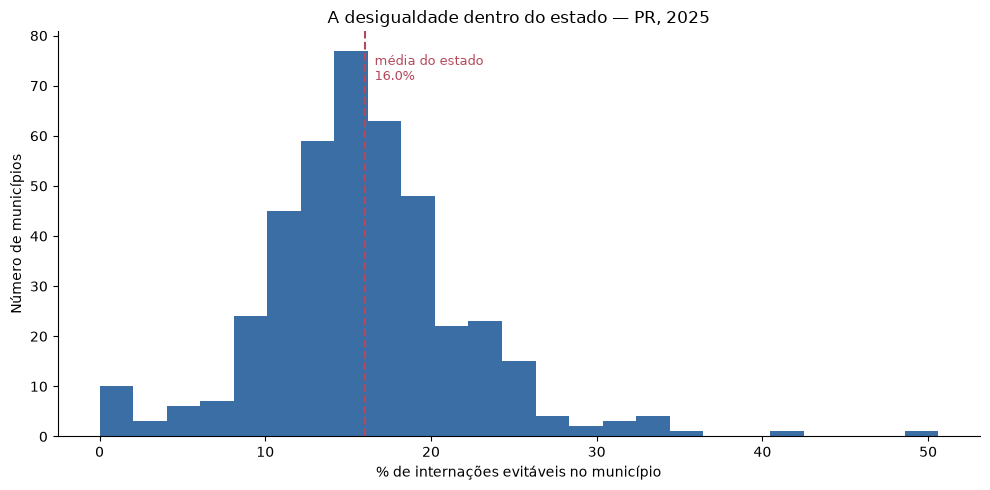

Do município com menor proporção ao com maior vão 51 pontos percentuais.


In [18]:
figura, eixo = plt.subplots(figsize=(10, 5))
eixo.hist(por_municipio["% sensíveis"], bins=25, color="#3b6ea5")
eixo.axvline(proporcao, color="#b5495b", linestyle="--", linewidth=1.5)
eixo.text(proporcao + 0.6, eixo.get_ylim()[1] * 0.88,
          f"média do estado\n{proporcao:.1f}%", color="#b5495b", fontsize=9)
eixo.set_xlabel("% de internações evitáveis no município")
eixo.set_ylabel("Número de municípios")
eixo.set_title(f"A desigualdade dentro do estado — {UF}, {ANO}", fontsize=12)
eixo.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

amplitude = por_municipio["% sensíveis"].max() - por_municipio["% sensíveis"].min()
print(f"Do município com menor proporção ao com maior vão "
      f"{amplitude:.0f} pontos percentuais.")

## 8. Conferindo com a realidade

In [19]:
letalidade = (elegiveis["MORTE"].astype(str) == "1").mean() * 100
letalidade_icsap = (sensiveis["MORTE"].astype(str) == "1").mean() * 100

print("Verificações de sanidade\n")
print(f"1. Proporção de ICSAP entre 10% e 35%?    {proporcao:.1f}% "
      f"({'sim' if 10 < proporcao < 35 else 'ATENÇÃO'})")
print(f"2. Permanência média entre 3 e 8 dias?    "
      f"{elegiveis['DIAS_PERM'].mean():.1f} "
      f"({'sim' if 3 < elegiveis['DIAS_PERM'].mean() < 8 else 'ATENÇÃO'})")
print(f"3. Letalidade hospitalar entre 3% e 10%?  {letalidade:.1f}% "
      f"({'sim' if 3 < letalidade < 10 else 'ATENÇÃO'})")
print(f"4. Curva de idade em U (mais no 1-4 e no 75+ que no 30-44)? "
      f"{'sim' if por_idade.loc['75+', '% sensíveis'] > por_idade.loc['30-44', '% sensíveis'] and por_idade.loc['1-4', '% sensíveis'] > por_idade.loc['30-44', '% sensíveis'] else 'ATENÇÃO'}")
print()
print(f"Letalidade das internações evitáveis: {letalidade_icsap:.1f}%")
print(f"Letalidade das demais:                "
      f"{(elegiveis[elegiveis['icsap'].isna()]['MORTE'].astype(str) == '1').mean() * 100:.1f}%")

Verificações de sanidade
1. Proporção de ICSAP entre 10% e 35%?    16.0% (sim)
2. Permanência média entre 3 e 8 dias?    4.2 (sim)
3. Letalidade hospitalar entre 3% e 10%?  4.3% (sim)
4. Curva de idade em U (mais no 1-4 e no 75+ que no 30-44)? sim
Letalidade das internações evitáveis: 4.8%


Letalidade das demais:                4.2%


Guarde esse último par de números, porque ele desfaz um mal-entendido comum.

**"Evitável" não quer dizer "leve".** As internações sensíveis à atenção
primária matam tanto quanto as demais — em muitos estados, mais. Basta olhar a
tabela por grupo: insuficiência cardíaca e doença cerebrovascular, dois dos
maiores blocos, têm letalidade perto de 9%. O que se evitaria com atenção
primária forte não é uma internação sem gravidade; é o acidente vascular
cerebral do hipertenso que ficou anos sem tratamento.

Uma ressalva sobre o período: os meses mais recentes do SIH ainda passam por
revisão das secretarias, e os números podem mudar um pouco. Para uma
publicação, prefira meses fechados há pelo menos um ano — e diga qual período
usou, sempre.

## 9. Como adaptar

| Você quer | Mude isto |
|---|---|
| Outro estado | `UF = "CE"` |
| Um ano inteiro | escolha um `ANO` com doze arquivos RD no catálogo |
| Só um município | filtre `internacoes["MUNIC_RES"] == "4106902"` |
| Comparar hospitais | agrupe por `CNES` em vez de `MUNIC_RES` |
| Só urgências | filtre `CAR_INT == "02"` (o caráter da internação) |
| Taxa por 10 mil habitantes | cruze `MUNIC_RES` com a população do IBGE — conferindo antes se o arquivo do ano está íntegro |
| Outra lista de causas | edite o dicionário `ICSAP`, que é a única fonte da classificação |

### O que vale levar

`grupo_icsap(diagnostico)` — a lista oficial em código auditável, com a regra
de testar quatro caracteres antes de três.
`idade_em_anos(idade, unidade)` — sem isso, todo recém-nascido do SIH vira
uma pessoa de poucos anos e a idade média do hospital desaba.

---

*Exemplo do repositório [PySusNoCode-Exemplos](https://github.com/cartaproale/PySusNoCode-Exemplos).
Dados: SIH/SUS, via biblioteca [PySUS](https://github.com/AlertaDengue/PySUS).
Notebook executado de verdade antes de publicado.*